Analyzing the 1/4 degree output of the ANHA EPM 151 run at /mnt/storage6/myers/NEMO/ANHA4-EPM151, primarily focusing on volume transports in and around the Grand Banks / Northwest Corner

In [1]:
import os

os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/" # setting config environment to writable directory to stop error message

import numpy as np
import xarray as xr
import glob
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

path = "/mnt/storage6/myers/NEMO/ANHA4-EPM151/"

Determined spatial domain to be the relatively small (150x150) grid from (lat, lon) -> (33.601116 - 57.051052; -67.03197 to -29.75201)

In [6]:
def preprocess_u_grid(ds):
    ds = ds[['vozocrtx']]
    ds = ds.sel(y=slice(225, 375))
    ds = ds.sel(x=slice(125,275))
    ds = ds.sel(depthu=slice(0,4000))
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d 39

def preprocess_v_grid(ds):
    ds = ds[['vomecrty']]
    ds = ds.sel(y=slice(225, 375)) 
    ds = ds.sel(x=slice(125,275)) # + 50, -75 in x; +25, -25 in y
    ds = ds.sel(depthv=slice(0,4000))
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d 39

def preprocess_t_grid(ds):
    ds = ds[['votemper', 'vosaline']]
    ds = ds.sel(y=slice(225, 375))
    ds = ds.sel(x=slice(125,275))
    ds = ds.sel(deptht=slice(0,4000))
    return ds # should have lat / lon, y / x dimensions of (150, 150) & d 39

def preprocess_bathy_grid(ds):
    ds = ds[['Bathymetry']]
    ds = ds.sel(y=slice(225, 375)) 
    ds = ds.sel(x=slice(125,275)) 
    return ds # should have lat / lon, y / x dimensions of (150, 150)

def get_u_grid():
    mdl_files_u = glob.glob(path+'ANHA4-EPM151_*_gridU.nc') #regex for all u-grid files
    ds_u = xr.open_mfdataset(mdl_files_u, preprocess = preprocess_u_grid, engine='netcdf4')
    return ds_u

def get_v_grid():
    mdl_files_v = glob.glob(path+'ANHA4-EPM151_*_gridV.nc') #regex for all v-grid files
    ds_v = xr.open_mfdataset(mdl_files_v, preprocess = preprocess_v_grid, engine='netcdf4')
    return ds_v
    
def get_t_grid():
    mdl_files_t = glob.glob(path+'ANHA4-EPM151_*_gridT.nc') #regex for all v-grid files
    ds_t = xr.open_mfdataset(mdl_files_t, preprocess = preprocess_t_grid, engine='netcdf4') # chunks 21
    return ds_t

def get_bathy():
    bathy = xr.open_mfdataset(path + 'ANHA4_bathy_etopo1_gebco1.nc', preprocess = preprocess_bathy_grid)
    return bathy

let's go i (horizontal) 0 -> 300 and j (vertical) 0 -> 450

(1) Cell below takes ~6 minutes to run with chunking in 100 intervals <br>
(2) takes less than 2 without chunking (toc/tic = time.perf_counter()) <br>
(3) takes about 5 minutes to run get_u_grid first time when the file was moved to storage6 from /home/ (oops) <br>
(4) when depth range reduced to 39, took 67 seconds <br>
    (4a) thought it was because I was repeating the same function; tried with v_grid and got 147.96 (2.3 mins) <br>
    (4b) turned out it was because I reduced the depth to 39 m rather than 39 levels; with 1500 m took (9.5) mins, then 2 minutes the    second time. <br>
    (4c) when I removed the ds.close() from the pre-processing function, took 4.25 minutes <br>
(5) when chunked @ 100 mb, took 6.85 minutes but the chunks didn't change?? <br>
(6) When chunks taken away, took ~3.85 minutes <br>
(7) no chunks new domain 4.3 minutes

BEST PRACTICE do not try and chunk and preprocess in the same open_mfdataset call. 

toc = time.perf_counter()
tic = time.perf_counter()
print(tic-toc)

In [5]:
ds_U = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2009m01d20_gridV.nc")

In [2]:
ds_T = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2009m01d20_gridT.nc")

In [6]:
ds_U

<xarray.Dataset> Size: 179MB
Dimensions:               (depthv: 50, axis_nbounds: 2, time_counter: 1,
                           y: 800, x: 544)
Coordinates:
  * depthv                (depthv) float32 200B 0.494 1.541 ... 5.728e+03
  * time_counter          (time_counter) object 8B 2009-01-18 12:00:00
    nav_lat               (y, x) float32 2MB dask.array<chunksize=(800, 544), meta=np.ndarray>
    nav_lon               (y, x) float32 2MB dask.array<chunksize=(800, 544), meta=np.ndarray>
    time_centered         (time_counter) object 8B dask.array<chunksize=(1,), meta=np.ndarray>
Dimensions without coordinates: axis_nbounds, y, x
Data variables:
    depthv_bounds         (depthv, axis_nbounds) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
    vomecrty              (time_counter, depthv, y, x) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
    time_centered_bounds  (time_counter, axis_nbounds) object 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) object 16B dask.array<chunksize=(1, 2), meta=np.ndarray>
    sometauy              (time_counter, y, x) float32 2MB dask.array<chunksize=(1, 800, 544), meta=np.ndarray>
    e3v                   (time_counter, depthv, y, x) float32 87MB dask.array<chunksize=(1, 50, 800, 544), meta=np.ndarray>
Attributes:
    name:         ANHA4-EPM151
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2022-Nov-19 16:04:37 EST

Do I have to re-chunk once I have opened them all as a dataset bc they're all different files?
(1) attempted re-chunking of ds_v (21 time steps): successful! <br>

BEST PRACTICE: re-chunk after opening with xarray, if necessary, using the inherent xarray re-chunking operation. <br> 

chunk sizes of 68 mb along the time axis did not improve performance significantly, so unnecessary in this case; with larger datasets see e.g. https://blog.dask.org/2021/11/02/choosing-dask-chunk-sizes?utm_source=xarray-docs <br>

e.g. ds_v_rechunked = ds_v.chunk({'time_counter':21})

Making a mask for land bathymetry variables (ocean values found by DATA = np.where(mask>0, DATA, np.nan))

Testing speed of taking & plotting means: <br>
(0) CONTROL, NO CHUNKS: One layer, one time, no means -- < 1 second
(1) FULL DEPTH MEAN, NO CHUNKS: all layers, one time, NO xr.compute() -- 1 second
(2) FULL TIME SERIES MEAN, no chunks: one layer, all times, no xr.compute() -- 5.1 minutes
(3) Full TIME FULL DEPTH, no chunks: .mean('time').mean('depth'), all layers, no xr.compute() -- 5.1 minutes 
(4) FULL DEPTH FULL TIME, no chunks: .mean('depth').mean('time'), all layers, no xr.compute() -- 5.1 minutes 

BEST PRACTICE doesn't matter whether you do depth or time first (when unchunked)

WHEN CHUNKED, 

depth -> time = 5 minutes
time -> depth = 5 minutes

BEST PRACTICE -> no improvement from chunking in this application, order doesn't matter

In [9]:
pos = np.arange(0,150,20)
x = ds_V.nav_lon[70, 55:90]
print(x.values)

NameError: name 'ds_V' is not defined

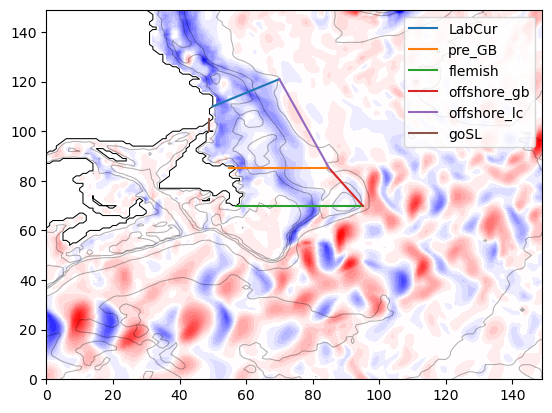

In [23]:
bathy = xr.open_mfdataset(path + 'ANHA4_bathy_etopo1_gebco1.nc')
mask_land = np.ma.make_mask(bathy['Bathymetry'] != 0)
bathy_levels = np.array([0, 100, 300, 1000, 3000, 5000])
bathy.close()

v = ds_V['vomecrty'][0, 0, :,:]
v = np.where(mask_land > 0, v, np.nan)

plt.contour(bathy['Bathymetry'][225:375,125:275], np.array([0, 100, 300, 1000, 3000, 5000]), colors = ['k']*len(bathy_levels), alpha = [1] + [.3]*(len(bathy_levels) -1), linewidths = .75)
plt.contourf(v[225:375, 125:275], np.arange(-1.5, 1.5, .05), cmap = 'seismic')
plt.plot([50, 70], [110, 121], label = 'LabCur') # x + 125 and y + 225 to get to model coords
plt.plot([55, 85], [85, 85], label = 'pre_GB')
plt.plot([57, 95], [70, 70], label = 'flemish')
plt.plot([85,95], [85,70],label = 'offshore_gb')
plt.plot([70,85], [121,85], label ='offshore_lc')
plt.plot([49,49], [105,100], label = 'goSL')

[250:450, 125:250]


x = ds_V.nav_lon[
Axes.set_xticklabels(

plt.legend()

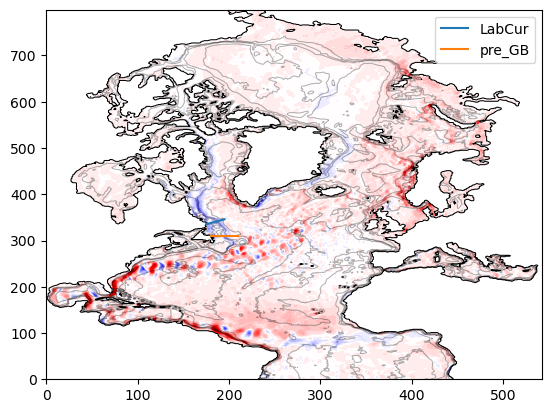

In [14]:
bathy = xr.open_mfdataset(path + 'ANHA4_bathy_etopo1_gebco1.nc')
mask_land = np.ma.make_mask(bathy['Bathymetry'] != 0)
bathy_levels = np.array([0, 100, 300, 1000, 3000, 5000])
bathy.close()

v = ds_V['vomecrty'][0, 0, :,:]
v = np.where(mask_land > 0, v, np.nan)

plt.contour(bathy['Bathymetry'], np.array([0, 100, 300, 1000, 3000, 5000]), colors = ['k']*len(bathy_levels), alpha = [1] + [.3]*(len(bathy_levels) -1), linewidths = .75)
plt.contourf(v, np.arange(-1.5, 1.5, .05), cmap = 'seismic')
plt.plot([50+125, 70+125], [110+225, 121+225], label = 'LabCur') # x + 125 and y + 225 to get to model coords
plt.plot([55+125, 85+125] , [85+225, 85+225], label = 'pre_GB')
#plt.plot([57, 95], [70, 70], label = 'flemish_cap')
#plt.plot([85,95], [85,70],label = 'offshore_gb')
#plt.plot([70,85], [121,85], label ='offshore_lc')
#plt.plot([49,49], [105,100], label = 'goSL')
plt.legend()

TypeError: 'Axes' object is not subscriptable

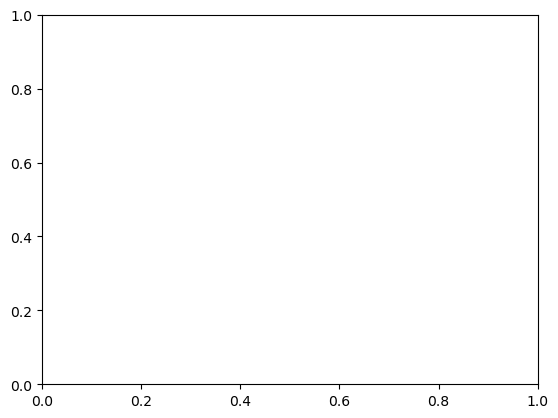

In [20]:
toc = time.perf_counter()

fig, ax = plt.subplots(1,1)

lab = ax[0,0].contourf(ds_V.nav_lon[85, 55:90], ds_V.depthv, ds_V['vomecrty'][:,:,85, 55:90].mean('time_counter'), np.arange(-.5, .5, .01), cmap = 'seismic')
ax[0,0].invert_yaxis()

"""
ax[0,1].contourf(ds_v_compute.nav_lon[85, 55:90], ds_v_compute.depthv, spring, np.arange(-.5, .5, .01), cmap = 'seismic')
ax[0,1].invert_yaxis()

ax[1,0].contourf(ds_v_compute.nav_lon[85, 55:90], ds_v_compute.depthv, summer, np.arange(-.5, .5, .01), cmap = 'seismic')
ax[1,0].invert_yaxis()

ax[1,1].contourf(ds_v_compute.nav_lon[85, 55:90], ds_v_compute.depthv, fall, np.arange(-.5, .5, .01), cmap = 'seismic')
ax[1,1].invert_yaxis()

#fig.colorbar(lab, ax = ax)
"""
tic = time.perf_counter()
print(tic-toc)


In [27]:
winter = ds_v_compute['vomecrty'][:,:36,70, 55:90].groupby('time_counter.season')['DJF'].mean('time_counter')
spring = ds_v_compute['vomecrty'][:,:36,70, 55:90].groupby('time_counter.season')['MAM'].mean('time_counter')
summer = ds_v_compute['vomecrty'][:,:36,70, 55:90].groupby('time_counter.season')['JJA'].mean('time_counter')
fall = ds_v_compute['vomecrty'][:,:36,70, 55:90].groupby('time_counter.season')['SON'].mean('time_counter')

0.028757378458976746


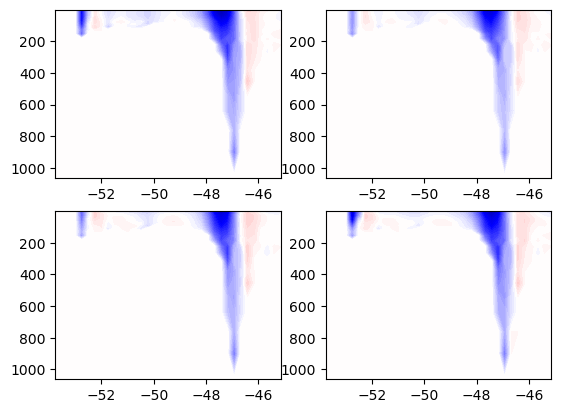

In [28]:
toc = time.perf_counter()

fig, ax = plt.subplots(2,2)

lab = ax[0,0].contourf(ds_v_compute.nav_lon[70, 55:90], ds_v_compute.depthv[:36], winter, np.arange(-.5, .5, .01), cmap = 'seismic')
ax[0,0].invert_yaxis()

ax[0,1].contourf(ds_v_compute.nav_lon[70, 55:90], ds_v_compute.depthv[:36], spring, np.arange(-.5, .5, .01), cmap = 'seismic')
ax[0,1].invert_yaxis()

ax[1,0].contourf(ds_v_compute.nav_lon[70, 55:90], ds_v_compute.depthv[:36], summer, np.arange(-.5, .5, .01), cmap = 'seismic')
ax[1,0].invert_yaxis()

ax[1,1].contourf(ds_v_compute.nav_lon[70, 55:90], ds_v_compute.depthv[:36], fall, np.arange(-.5, .5, .01), cmap = 'seismic')
ax[1,1].invert_yaxis()

#fig.colorbar(lab, ax = ax)

tic = time.perf_counter()
print(tic-toc)

In [3]:
trans_labcur = xr.open_mfdataset('/mnt/storage6/grace/nwcorner/scripts/Figures/lab_cur_volume_transport_EPM151.nc')
#trans_pregb = xr.open_mfdataset('/mnt/storage6/grace/nwcorner/scripts/Figures/pre_GB_volume_transport_EPM151.nc')
#trans_flemish = xr.open_mfdataset('/mnt/storage6/grace/nwcorner/scripts/Figures/flemish_volume_transport_EPM151.nc')

In [4]:
type(trans_labcur.time_counter.values[0])

cftime._cftime.DatetimeNoLeap

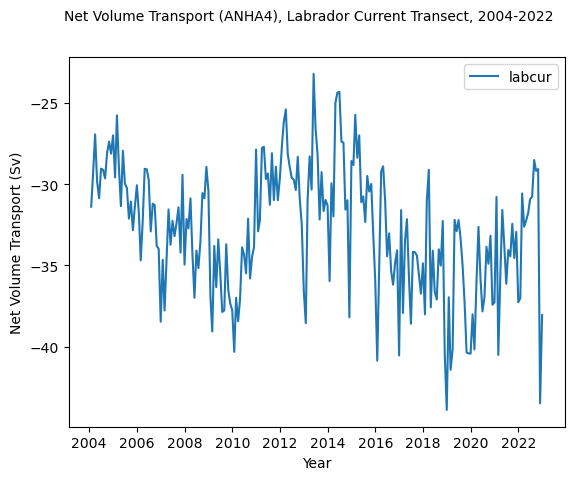

In [10]:
plt.plot(trans_labcur.time_counter.values.astype("datetime64[ns]"), trans_labcur['vel'].values, label = 'labcur')
#plt.plot(trans_pregb.time_counter.values.astype("datetime64[ns]"), trans_pregb['vel'].values, label = 'pre_GB')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_flemish['vel'].values, label = 'flemish')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_pregb['vel'].values - trans_labcur['vel'].values, label = 'offshelf transport 53N GB', linestyle = '--', c = 'blue')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_flemish['vel'].values - trans_pregb['vel'].values, label = 'offshelf transport GB Flemish', linestyle = '--', c = 'green')
plt.suptitle('Net Volume Transport (ANHA4), Labrador Current Transect, 2004-2022', fontsize=10)
plt.xlabel("Year")
plt.ylabel("Net Volume Transport (Sv)")
plt.legend()

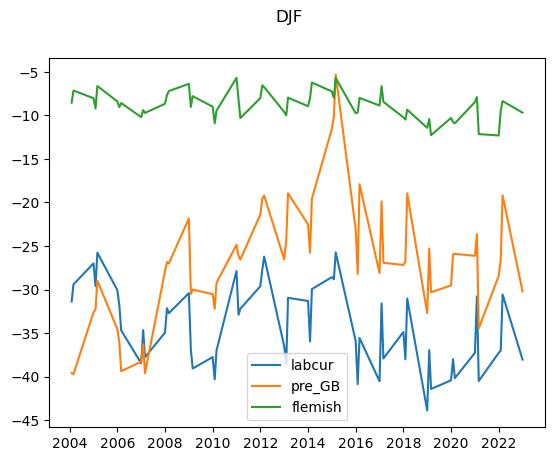

In [48]:
plt.plot(trans_labcur.time_counter.groupby('time_counter.season')['DJF'].values.astype("datetime64[ns]"), trans_labcur['vel'].groupby('time_counter.season')['DJF'].values, label = 'labcur')
plt.plot(trans_pregb.time_counter.groupby('time_counter.season')['DJF'].values.astype("datetime64[ns]"), trans_pregb['vel'].groupby('time_counter.season')['DJF'].values, label = 'pre_GB')
plt.plot(trans_flemish.time_counter.groupby('time_counter.season')['DJF'].values.astype("datetime64[ns]"), trans_flemish['vel'].groupby('time_counter.season')['DJF'].values, label = 'flemish')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_pregb['vel'].values - trans_labcur['vel'].values, label = 'offshelf transport 53N GB', linestyle = '--', c = 'blue')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_flemish['vel'].values - trans_pregb['vel'].values, label = 'offshelf transport GB Flemish', linestyle = '--', c = 'green')
plt.suptitle('DJF')
plt.legend()

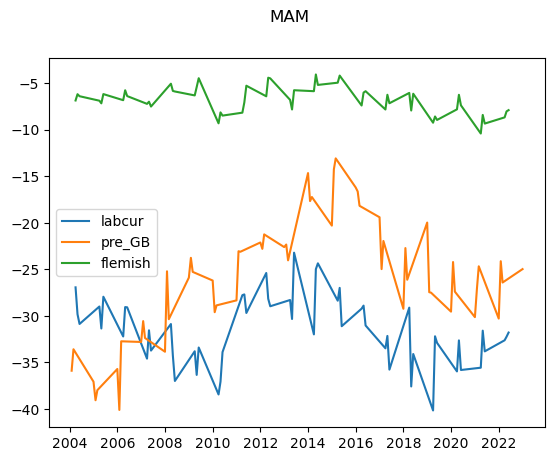

In [54]:
plt.plot(trans_labcur.time_counter.groupby('time_counter.season')['MAM'].values.astype("datetime64[ns]"), trans_labcur['vel'].groupby('time_counter.season')['MAM'].values, label = 'labcur')
plt.plot(trans_pregb.time_counter.groupby('time_counter.season')['DJF'].values.astype("datetime64[ns]"), trans_pregb['vel'].groupby('time_counter.season')['MAM'].values, label = 'pre_GB')
plt.plot(trans_flemish.time_counter.groupby('time_counter.season')['MAM'].values.astype("datetime64[ns]"), trans_flemish['vel'].groupby('time_counter.season')['MAM'].values, label = 'flemish')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_pregb['vel'].values - trans_labcur['vel'].values, label = 'offshelf transport 53N GB', linestyle = '--', c = 'blue')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_flemish['vel'].values - trans_pregb['vel'].values, label = 'offshelf transport GB Flemish', linestyle = '--', c = 'green')
plt.suptitle('MAM')
plt.legend()

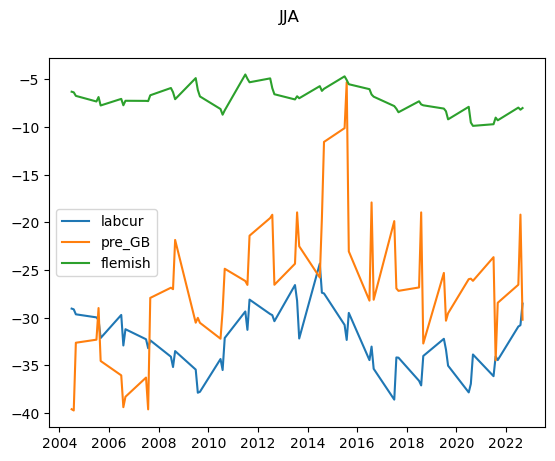

In [53]:
plt.plot(trans_labcur.time_counter.groupby('time_counter.season')['JJA'].values.astype("datetime64[ns]"), trans_labcur['vel'].groupby('time_counter.season')['JJA'].values, label = 'labcur')
plt.plot(trans_pregb.time_counter.groupby('time_counter.season')['JJA'].values.astype("datetime64[ns]"), trans_pregb['vel'].groupby('time_counter.season')['DJF'].values, label = 'pre_GB')
plt.plot(trans_flemish.time_counter.groupby('time_counter.season')['JJA'].values.astype("datetime64[ns]"), trans_flemish['vel'].groupby('time_counter.season')['JJA'].values, label = 'flemish')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_pregb['vel'].values - trans_labcur['vel'].values, label = 'offshelf transport 53N GB', linestyle = '--', c = 'blue')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_flemish['vel'].values - trans_pregb['vel'].values, label = 'offshelf transport GB Flemish', linestyle = '--', c = 'green')
plt.suptitle('JJA')
plt.legend()

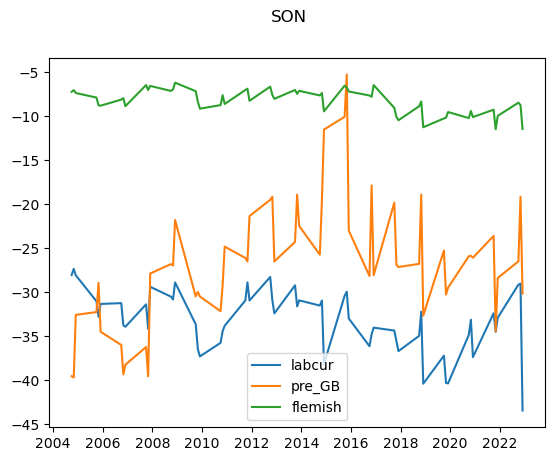

In [52]:
plt.plot(trans_labcur.time_counter.groupby('time_counter.season')['SON'].values.astype("datetime64[ns]"), trans_labcur['vel'].groupby('time_counter.season')['SON'].values, label = 'labcur')
plt.plot(trans_pregb.time_counter.groupby('time_counter.season')['SON'].values.astype("datetime64[ns]"), trans_pregb['vel'].groupby('time_counter.season')['DJF'].values, label = 'pre_GB')
plt.plot(trans_flemish.time_counter.groupby('time_counter.season')['SON'].values.astype("datetime64[ns]"), trans_flemish['vel'].groupby('time_counter.season')['SON'].values, label = 'flemish')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_pregb['vel'].values - trans_labcur['vel'].values, label = 'offshelf transport 53N GB', linestyle = '--', c = 'blue')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_flemish['vel'].values - trans_pregb['vel'].values, label = 'offshelf transport GB Flemish', linestyle = '--', c = 'green')
plt.suptitle('SON')
plt.legend()

In [2]:
trans_labcur

NameError: name 'trans_labcur' is not defined

In [ ]:
plt.plot(trans_labcur.time_counter.values.astype("datetime64[ns]"), trans_labcur['vel'].values, label = 'labcur')
#plt.plot(trans_pregb.time_counter.values.astype("datetime64[ns]"), trans_pregb['vel'].values, label = 'pre_GB')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_flemish['vel'].values, label = 'flemish')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_pregb['vel'].values - trans_labcur['vel'].values, label = 'offshelf transport 53N GB', linestyle = '--', c = 'blue')
#plt.plot(trans_flemish.time_counter.values.astype("datetime64[ns]"), trans_flemish['vel'].values - trans_pregb['vel'].values, label = 'offshelf transport GB Flemish', linestyle = '--', c = 'green')
plt.suptitle('Net Volume Transport (ANHA4), Labrador Current Transect, 2004-2022', fontsize=10)
plt.xlabel("Year")
plt.ylabel("Net Volume Transport (Sv)")
plt.legend()